## Primer Paso

### Pre-Algorithm


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
# función auxiliar para evaluar si nuestro modelo está sobreajustado o subajustado
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))
# eval_metric(Logistic_model, X_train, y_train, X_test, y_test)
# xgboost tiene validación cruzada.

In [ ]:
!pip install numpy==1.26.4 scipy==1.14.1 pandas==2.2.2 joblib==1.4.2 threadpoolctl==3.6.0 matplotlib==3.9.3
!pip install -q scikit-learn==1.6.1 lightgbm==4.5.0 catboost==1.2.7
!pip install -q scapy==2.5.0
!pip install -q tensorflow==2.18.0
!pip install -q optuna==4.2.1
!pip install -q shap==0.46.0 lime==0.2.0.1
!pip install -q deap==1.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.2
    Uninstalling joblib-1.5.2:
      Successfully uninstalled joblib-1.5.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
  Attempting uninstall: matplotlib
    Found existing installation: matplo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which

In [ ]:
import joblib
import os

def save_model(modelo, nombre_archivo):
    """
    Guarda un modelo entrenado utilizando joblib en una ruta específica.

    entonces recibe los parámetros:
        modelo: El modelo entrenado a guardar.
        nombre_archivo (str): Nombre del archivo sin extensión.

    Retorna:
        ruta_completa (str): La ruta completa donde se guardó el modelo.
    """
    modelo_dir = '/content/drive/MyDrive/Modelos'  # Ruta donde se guardarán los modelos
    if not os.path.exists(modelo_dir):
        os.makedirs(modelo_dir)  # crea el directorio si no existe

    ruta_completa = os.path.join(modelo_dir, f"{nombre_archivo}.pkl")  # Nombre completo
    joblib.dump(modelo, ruta_completa)
    print(f"Modelo guardado correctamente en: {ruta_completa}")
    return ruta_completa

def load_model(nombre_archivo):
    """
    Carga un modelo entrenado utilizando joblib desde una ruta específica.

    Parámetros:
        nombre_archivo (str): Nombre del archivo del modelo sin extensión.

    Retorna:
        modelo: El modelo cargado desde la ruta.
    """
    modelo_dir = '/content/drive/MyDrive/Modelos'  # Ruta donde están los modelos guardados
    ruta_completa = os.path.join(modelo_dir, f"{nombre_archivo}.pkl")

    if not os.path.exists(ruta_completa):
        raise FileNotFoundError(f"No se encontró el modelo en la ruta: {ruta_completa}")

    modelo = joblib.load(ruta_completa)
    print(f"Modelo cargado correctamente desde: {ruta_completa}")
    return modelo



### Libraries

In [ ]:
# =========================================
# Código Final Final para NSL-KDD en Google Colab
# =========================================

import itertools
import json
import os
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
import lightgbm as lgb

from catboost import CatBoostClassifier
from joblib import dump, load
from pandas.api.types import is_numeric_dtype

from sklearn import preprocessing
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    roc_curve
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

SEED_FIRST_TRAIN = 43
SEED_SECOND_TRAIN = 0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/nsl-kdd'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/nsl-kdd/KDDTest-21.arff
/content/drive/MyDrive/nsl-kdd/KDDTest+.arff
/content/drive/MyDrive/nsl-kdd/KDDTest-21.txt
/content/drive/MyDrive/nsl-kdd/KDDTest1.jpg
/content/drive/MyDrive/nsl-kdd/KDDTest+.txt
/content/drive/MyDrive/nsl-kdd/KDDTrain+.arff
/content/drive/MyDrive/nsl-kdd/KDDTrain+_20Percent.arff
/content/drive/MyDrive/nsl-kdd/KDDTrain+_20Percent.txt
/content/drive/MyDrive/nsl-kdd/KDDTrain+.txt
/content/drive/MyDrive/nsl-kdd/KDDTrain1.jpg
/content/drive/MyDrive/nsl-kdd/index.html
/content/drive/MyDrive/nsl-kdd/test_data_cont.csv
/content/drive/MyDrive/nsl-kdd/X_test_scaled.csv
/content/drive/MyDrive/nsl-kdd/test_data_cont.json
/content/drive/MyDrive/nsl-kdd/X_train_scaled.csv
/content/drive/MyDrive/nsl-kdd/nsl-kdd/KDDTest+.arff
/content/drive/MyDrive/nsl-kdd/nsl-kdd/KDDTest+.txt
/content/drive/MyDrive/nsl-kdd/nsl-kdd/KDDTest-21.txt
/content/drive/MyDrive/nsl-kdd/nsl-kdd/KDDTest1.jpg
/content/drive/MyDrive/nsl-kdd/nsl-kdd/KDDTest-21.arff
/content/drive/MyDr

In [ ]:
train=pd.read_csv('/content/drive/MyDrive/nsl-kdd/KDDTrain+.txt')
# test=pd.read_csv('/content/drive/MyDrive/nsl-kdd/KDDTest+.txt')
### https://www.kaggle.com/code/eneskosar19/intrusion-detection-system-nsl-kdd

### ADJUST COLUMNS

In [ ]:
train.columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
'num_access_files', 'num_outbound_cmds', 'is_host_login',
'is_guest_login', 'count', 'srv_count', 'serror_rate',
'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
'dst_host_srv_count', 'dst_host_same_srv_rate','dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
'dst_host_srv_rerror_rate', 'attack','level']

### DATA CLEANING

In [ ]:
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
# esta es la función auxiliar para un análisis más profundo
def unique_values(train, columns):
    """Imprime los valores únicos y sus recuentos para columnas específicas en el DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = train[column_name].unique()
        value_counts = train[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [ ]:
cat_features = train.select_dtypes(include='object').columns
unique_values(train, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['udp' 'tcp' 'icmp']

Value Counts:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6859
 

### DUPLICATES

In [ ]:
train.duplicated().sum()
# El conjunto de datos no contiene ninguna fila duplicada
## outliers // valores atipicos
# No hay demasiados valores atípicos como para confundir al modelo, por lo que no eliminaré los valores atípicos.

np.int64(0)

### CLASSIFY ATTACK OR NOT

In [ ]:
attack_n = []
for i in train.attack :
  if i == 'normal':
    attack_n.append("normal")
  else:
    attack_n.append("attack")
train['attack'] = attack_n

In [ ]:
train['attack'].unique()

array(['normal', 'attack'], dtype=object)

### Service used general

/tmp/ipython-input-71115551.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotated labels


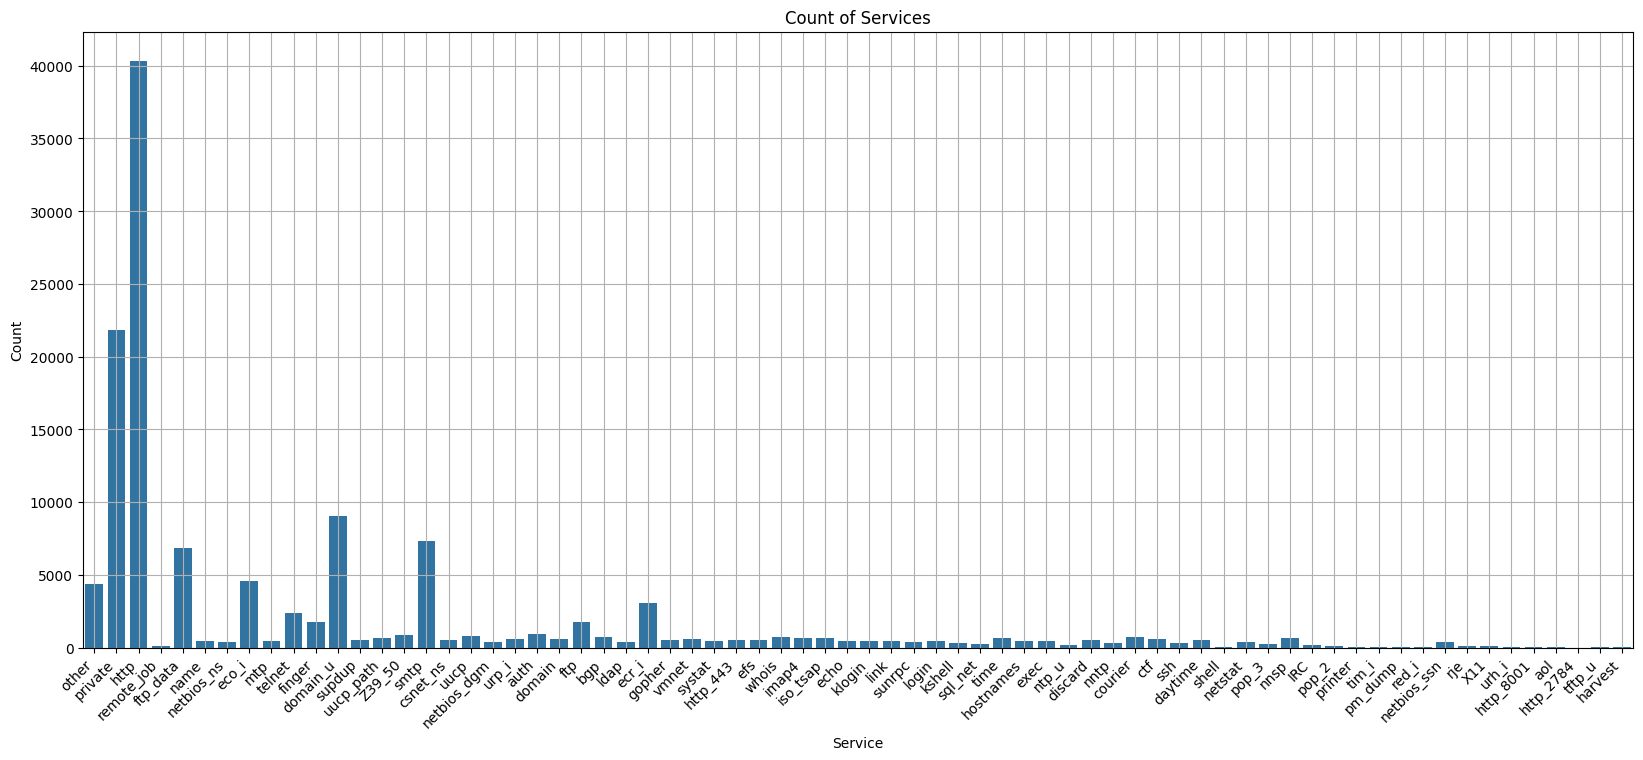

In [ ]:
plt.figure(figsize=(20, 8))  # Tamaño de figura ajustado
ax = sns.countplot(x='service', data=train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Etiquetas rotadas
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Count of Services')
plt.grid(True)
plt.show()
# Los servicios más utilizados en general son: http,private,domain_u,smtp,ftp,other..


### Service used effect on attacks

/tmp/ipython-input-88411601.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotated labels


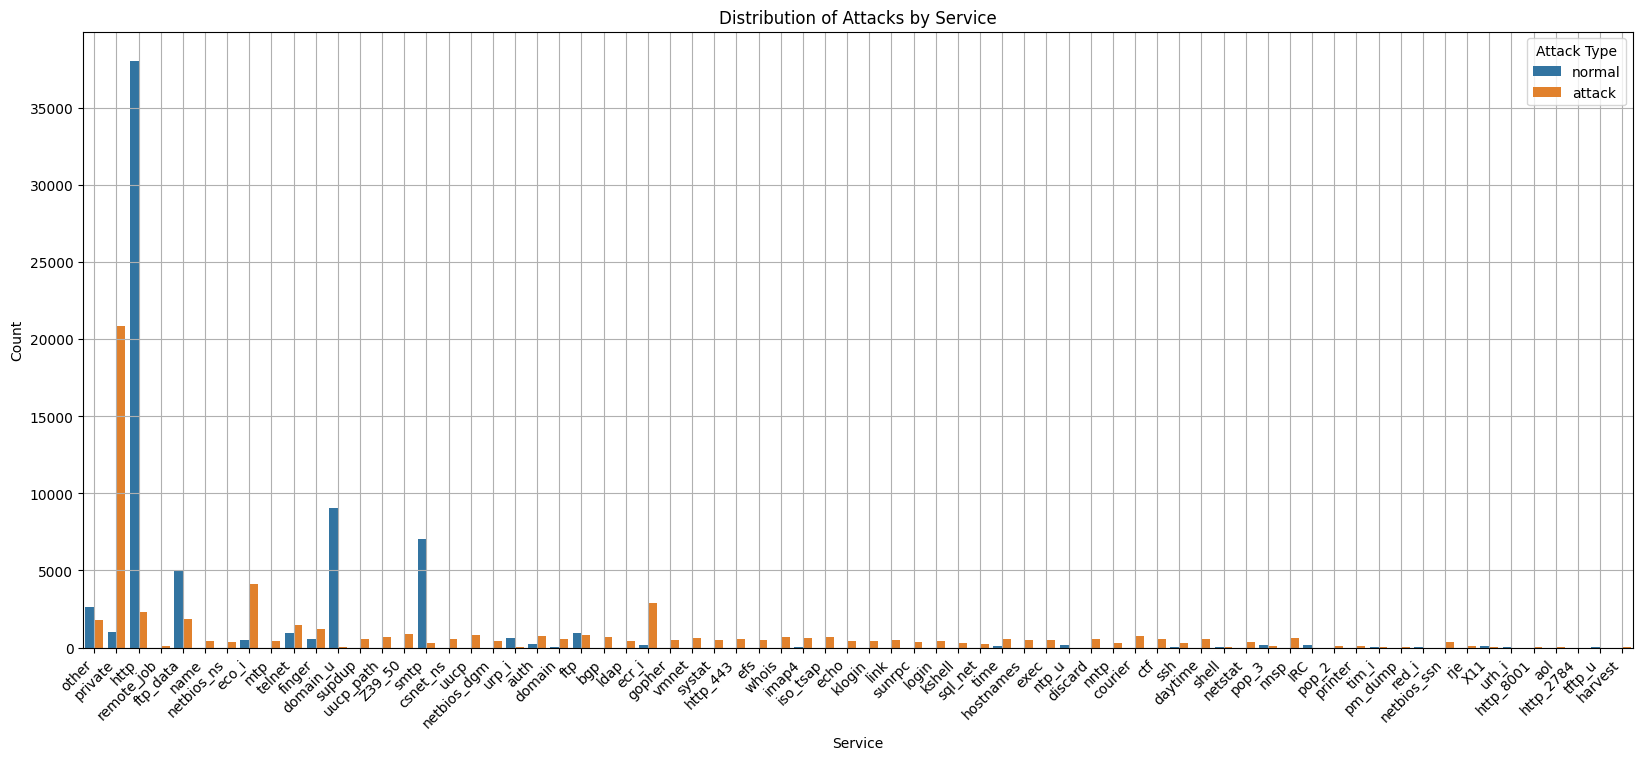

In [ ]:
plt.figure(figsize=(20, 8))  # Tamaño de figura ajustado
ax = sns.countplot(x='service', hue='attack', data=train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Etiquetas rotadas
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Distribution of Attacks by Service')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()
# vemos que los ataques privados son el servicio más común

### PREPROCESSING

In [ ]:
#### ENCODING
cat_features = train.select_dtypes(include='object').columns
cat_features


Index(['protocol_type', 'service', 'flag', 'attack'], dtype='object')

In [ ]:
le=preprocessing.LabelEncoder()
clm=['protocol_type', 'service', 'flag', 'attack']
for x in clm:
    train[x]=le.fit_transform(train[x])

In [ ]:
#### TRAIN-TEST-SPLIT
X = train.drop(["attack"], axis=1)
y = train["attack"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1,random_state=SEED_FIRST_TRAIN)
train_index = X_train.columns
train_index

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

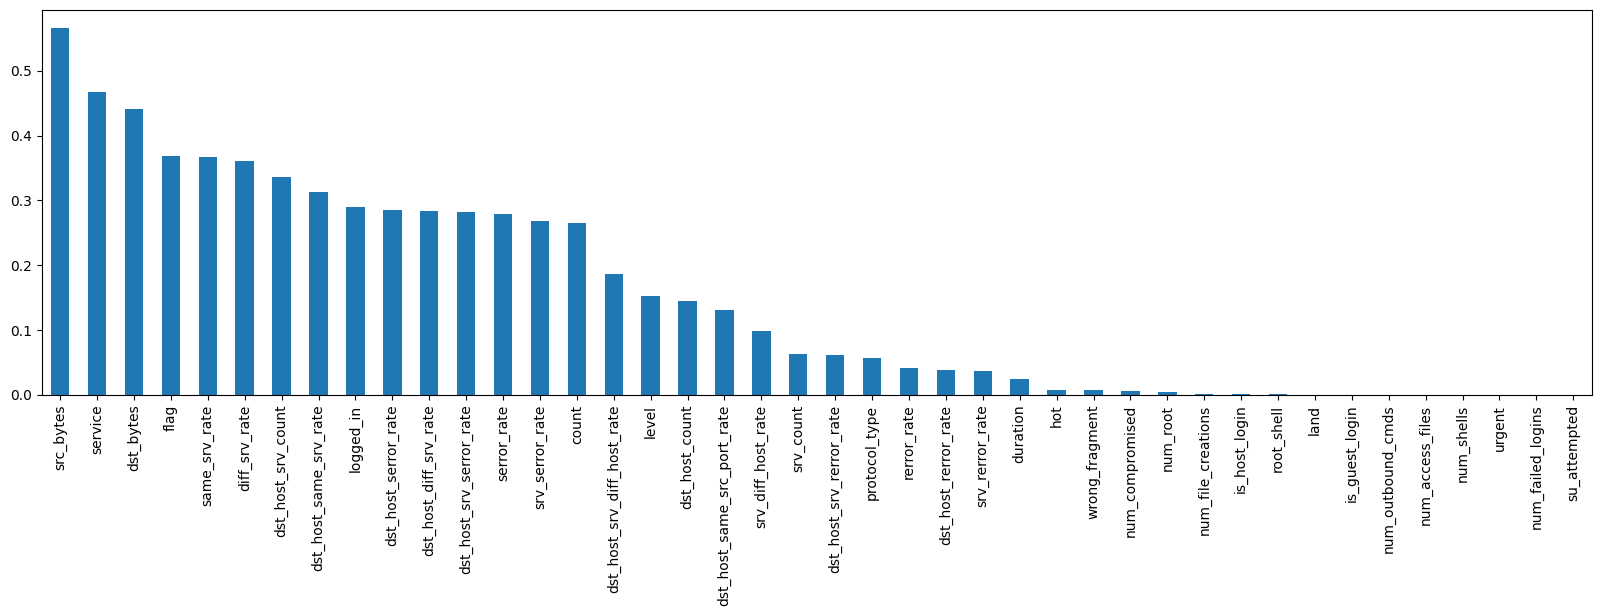

In [ ]:
####  Ingeniería de características
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

In [ ]:
#### Selección de funciones
Select_features = SelectKBest(mutual_info_classif, k=30)
Select_features.fit(X_train, y_train)
train_index[Select_features.get_support()]

columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
       'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate']

# para el fit de los modelo sera con 15 características
# principales, porque el conjunto de datos es grande.

X_train=X_train[columns]
X_test=X_test[columns]

In [ ]:
#### Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # únicamente transformación para evitar fugas de datos

## HYPERPARAMETER TUNING (optuna)

### XGB

In [ ]:
def objective(trial):
    # Definir los parámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 50, 128)
    max_depth = trial.suggest_int('max_depth', 2, 6)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.1)
    subsample = trial.suggest_categorical('subsample', [0.5, 0.8])
    colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.5, 0.8])

    # Inicializar el modelo
    XGB = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42
    )

    # Entrenar el modelo
    XGB.fit(X_train, y_train)

    # Evaluar el modelo
    y_pred = XGB.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    return f1


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_score = study.best_value
best_params = study.best_trial.params

# Entrenar el modelo final con los mejores hiperparámetros
XGB_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    random_state=42
)

# Medir el tiempo de entrenamiento
start_time = time.time()
XGB_model.fit(X_train, y_train)
end_time = time.time()
cld_train = end_time-start_time
print("Training time: ", cld_train)

# Medir el tiempo de predicción
start_time = time.time()
y_pred = XGB_model.predict(X_test)
end_time = time.time()
cld_test = end_time-start_time
print("Testing time: ", cld_test)

# Evaluar y mostrar los resultados
print(f"F1 Score: {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

CLF_train, CLF_test = XGB_model.score(X_train, y_train), XGB_model.score(X_test, y_test)
print(f"Train Score: {CLF_train}")
print(f"Test Score: {CLF_test}")

# Imprimir los mejores hiperparámetros
print("Best hyperparameters: ", best_params)
print("Best score: ", best_score)


[I 2024-08-11 19:40:56,719] A new study created in memory with name: no-name-4685d62f-85ca-4188-9b94-f811a0686271
<ipython-input-26-9a31375379ab>:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.1)
[I 2024-08-11 19:40:57,723] Trial 0 finished with value: 0.981836899772042 and parameters: {'n_estimators': 96, 'max_depth': 3, 'learning_rate': 0.012519703161951556, 'subsample': 0.5, 'colsample_bytree': 0.5}. Best is trial 0 with value: 0.981836899772042.
<ipython-input-26-9a31375379ab>:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.1)
[I 202

Training time:  1.2378919124603271
Testing time:  0.028213024139404297
F1 Score: 99.68%
Accuracy Score: 99.65%
Train Score: 0.9965335967682185
Test Score: 0.9965073821241467
Best hyperparameters:  {'n_estimators': 111, 'max_depth': 5, 'learning_rate': 0.05334849274184868, 'subsample': 0.5, 'colsample_bytree': 0.8}
Best score:  0.9967518086520006


In [ ]:
# Guardar el modelo entrenado
save_model(XGB_model, 'XGB_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_XGB = load_model('XGB_model.pkl')

Model saved to XGB_model.pkl
Model loaded from XGB_model.pkl


### EVALUATION

In [ ]:
y_pred = XGB_model.predict(X_test)
y_pred_proba = XGB_model.predict_proba(X_test)

xgb_f1 = f1_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_pred_proba[:,1])
xgb_auc

0.999785657585395

### SVC

In [ ]:
def objective_svc(trial):
    # Parámetros a optimizar
    kernel = trial.suggest_categorical('kernel', ['rbf', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 0.001, 10, log=True)

    # Entrenar el modelo
    svc = SVC(kernel=kernel, gamma=gamma)
    svc.fit(X_train, y_train)

    # Evaluar en conjunto de testing
    y_pred = svc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

# Crear y optimizar el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective_svc, n_trials=10)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_params = study.best_trial.params
best_score = study.best_value

# Entrenar el modelo final con los mejores hiperparámetros
best_svc = SVC(kernel=best_params['kernel'], gamma=best_params['gamma'])

# Medir el tiempo de entrenamiento
start_time = time.time()
best_svc.fit(X_train, y_train)
end_time = time.time()
svc_train = end_time - start_time
print("Training time: ", svc_train)

# Medir el tiempo de predicción
start_time = time.time()
y_pred = best_svc.predict(X_test)
end_time = time.time()
svc_test = end_time - start_time
print("Testing time: ", svc_test)

# Evaluar y mostrar los resultados
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')  # Ajuste para varias clases si es necesario

print(f"F1 Score: {f1 * 100:.2f}%")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

SVC_train, SVC_test = best_svc.score(X_train, y_train), best_svc.score(X_test, y_test)
print(f"Train Score: {SVC_train}")
print(f"Test Score: {SVC_test}")

# Imprimir los mejores hiperparámetros y la mejor puntuación
print("Best hyperparameters: ", best_params)
print("Best score: ", best_score)

# Guardar y mostrar las predicciones como DataFrames
y_val_pred1_split1 = pd.DataFrame(y_pred)
y_test_pred1_split1 = pd.DataFrame(best_svc.predict(X_test))

[I 2024-08-11 19:52:33,668] A new study created in memory with name: no-name-4705ec84-2e9e-4fd6-9342-f778052f6e01
[I 2024-08-11 19:58:09,313] Trial 0 finished with value: 0.9277663121130338 and parameters: {'kernel': 'sigmoid', 'gamma': 0.009495242661016094}. Best is trial 0 with value: 0.9277663121130338.
[I 2024-08-11 20:13:26,647] Trial 1 finished with value: 0.7761549452294015 and parameters: {'kernel': 'sigmoid', 'gamma': 6.8533778415343765}. Best is trial 0 with value: 0.9277663121130338.
[I 2024-08-11 20:23:44,454] Trial 2 finished with value: 0.8616447055088109 and parameters: {'kernel': 'sigmoid', 'gamma': 0.1818319565314199}. Best is trial 0 with value: 0.9277663121130338.
[I 2024-08-11 20:38:58,292] Trial 3 finished with value: 0.7762343229083981 and parameters: {'kernel': 'sigmoid', 'gamma': 6.990577123799062}. Best is trial 0 with value: 0.9277663121130338.
[I 2024-08-11 20:44:56,176] Trial 4 finished with value: 0.8243371963803778 and parameters: {'kernel': 'sigmoid', 'ga

Training time:  507.9090814590454
Testing time:  4.53720498085022
F1 Score: 98.39%
Accuracy Score: 98.39%
Train Score: 0.9829325947748161
Test Score: 0.9838863311636767
Best hyperparameters:  {'kernel': 'rbf', 'gamma': 1.813774911288711}
Best score:  0.9838863311636767


In [ ]:
# Guardar el modelo entrenado
save_model(best_svc, 'svc_best_clf_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_svc = load_model('svc_best_clf_model.pkl')

Model saved to svc_best_clf_model.pkl
Model loaded from svc_best_clf_model.pkl


In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.2 MB/s eta 0:00:00


### GNB Genetico Clonal

In [ ]:
# DEAP
from deap import base, creator, tools, algorithms

# Solo crea las clases si no existen ya
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Definir el rango de los parámetros (asegurar que sea positivo)
toolbox.register("var_smoothing", random.uniform, 1e-10, 1e-1)

# Crear un individuo y una población
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.var_smoothing,), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Evaluación del individuo
def evaluate(individual):
    var_smoothing = max(1e-10, individual[0])  # Asegurarse de que sea positivo
    gnb = GaussianNB(var_smoothing=var_smoothing)
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy,

# Configuración del algoritmo genético
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)

# Mutación adaptada para mantener los valores en el rango positivo
def mut_positive(individual, mu, sigma, indpb):
    for i in range(len(individual)):
        if random.random() < indpb:
            individual[i] += random.gauss(mu, sigma)
            # Asegurar que el valor permanezca dentro del rango válido
            individual[i] = max(1e-10, individual[i])
    return individual,

toolbox.register("mutate", mut_positive, mu=0, sigma=1e-2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Algoritmo Clonal (Optuna)
def objective(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True)
    gnb = GaussianNB(var_smoothing=var_smoothing)
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Optimización combinada
population = toolbox.population(n=10)
ngen = 10
cxpb = 0.5
mutpb = 0.2

# Algoritmo genético básico
for gen in range(ngen):
    offspring = algorithms.varAnd(population, toolbox, cxpb, mutpb)
    for ind in offspring:
        ind[0] = max(1e-10, ind[0])  # Asegurarse de que sea positivo

    fits = [toolbox.evaluate(ind) for ind in offspring]
    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    population = toolbox.select(offspring, k=len(population))

    # Algoritmo Clonal usando Optuna en cada generación
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=5)

    # Tomar el mejor resultado de la generación actual
    best_individual = tools.selBest(population, k=1)[0]
    best_params = study.best_trial.params

    # Actualizar el mejor individuo de la población
    best_individual[0] = best_params['var_smoothing']

# Entrenamiento final con el mejor modelo
best_var_smoothing = best_individual[0]
gnb = GaussianNB(var_smoothing=best_var_smoothing)

start_time = time.time()
gnb.fit(X_train, y_train)
end_time = time.time()
gnb_train = end_time - start_time
print("Training time: ", gnb_train)

start_time = time.time()
y_pred = gnb.predict(X_test)
end_time = time.time()
gnb_test = end_time - start_time
print("Testing time: ", gnb_test)

# Evaluación final
GNB_train, GNB_test = gnb.score(X_train, y_train), gnb.score(X_test, y_test)
print(f"Train Score: {GNB_train}")
print(f"Test Score: {GNB_test}")

print("Best var_smoothing: ", best_var_smoothing)

[I 2024-08-11 23:46:47,055] A new study created in memory with name: no-name-07a01dd8-9479-40b7-9fb3-892955bbd285
[I 2024-08-11 23:46:47,191] Trial 0 finished with value: 0.8918082235275441 and parameters: {'var_smoothing': 0.0055921409745111565}. Best is trial 0 with value: 0.8918082235275441.
[I 2024-08-11 23:46:47,260] Trial 1 finished with value: 0.9024448325130974 and parameters: {'var_smoothing': 8.118701921997451e-08}. Best is trial 1 with value: 0.9024448325130974.
[I 2024-08-11 23:46:47,348] Trial 2 finished with value: 0.8837117002698841 and parameters: {'var_smoothing': 0.00021227768575668587}. Best is trial 1 with value: 0.9024448325130974.
[I 2024-08-11 23:46:47,426] Trial 3 finished with value: 0.9029210985870774 and parameters: {'var_smoothing': 9.392133301659158e-08}. Best is trial 3 with value: 0.9029210985870774.
[I 2024-08-11 23:46:47,520] Trial 4 finished with value: 0.8953008414033974 and parameters: {'var_smoothing': 1.6232591425057444e-08}. Best is trial 3 with v

Training time:  0.07792544364929199
Testing time:  0.0033369064331054688
Train Score: 0.9064247534708134
Test Score: 0.9029210985870774
Best var_smoothing:  9.333250802901897e-08


In [ ]:

# Guardar el modelo entrenado
joblib.dump(gnb, 'gnb_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_lg_model = joblib.load('gnb_model.pkl')

### Logistic Regression

In [ ]:
def objective_logistic_regression(trial):
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
    C = trial.suggest_float('C', 0.01, 100)
    model = LogisticRegression(solver=solver, C=C)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective_logistic_regression, n_trials=100)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_params = study.best_trial.params
best_score = study.best_trial.value
print(f"Best Hyperparameters: {best_params}")
print(f"Best Score: {best_score}")

# Entrenar el modelo final con los mejores hiperparámetros
lg_model = LogisticRegression(solver=best_params['solver'], C=best_params['C'])

start_time = time.time()
lg_model.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time} seconds")

# Medir el tiempo de predicción
start_time = time.time()
y_test_pred = lg_model.predict(X_test)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Prediction time: {prediction_time} seconds")

# Evaluar y mostrar los resultados
train_score = lg_model.score(X_train, y_train)
test_score = lg_model.score(X_test, y_test)
print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

# Guardar y mostrar las predicciones como DataFrames
y_test_pred_df = pd.DataFrame(y_test_pred, columns=['Prediction'])
print(y_test_pred_df.head())

# Guardar el modelo entrenado
joblib.dump(lg_model, 'logistic_regression_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_lg_model = joblib.load('logistic_regression_model.pkl')


[I 2024-08-11 23:51:57,940] A new study created in memory with name: no-name-0c526f54-767d-422a-9782-295d6fa017c5
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[I 2024-08-11 23:52:00,293] Trial 0 finished with value: 0.9458644229242736 and parameters: {'solver': 'lbfgs', 'C': 34.18491381697444}. Best is trial 0 with value: 0.9458644229242736.
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase

Best Hyperparameters: {'solver': 'liblinear', 'C': 0.9000594710247967}
Best Score: 0.9491982854421337
Training time: 1.4072809219360352 seconds
Prediction time: 0.0019147396087646484 seconds
Train Score: 0.950385449926791
Test Score: 0.9491982854421337
   Prediction
0           1
1           1
2           0
3           1
4           0


### Decision Three

In [ ]:
# Función objetivo para Optuna
def objective_decision_tree(trial):
    # rango de sugerencia de valores para los hiperparámetros
    dt_max_depth = trial.suggest_int('max_depth', 3, 30)
    dt_min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    dt_max_features = trial.suggest_int('max_features', 1, X_train.shape[1])

    # Inicializar y entrenar el modelo con los hiperparámetros sugeridos
    model = DecisionTreeClassifier(
        max_depth=dt_max_depth,
        min_samples_split=dt_min_samples_split,
        max_features=dt_max_features,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Evaluar en el conjunto de prueba
    accuracy = model.score(X_test, y_test)
    return accuracy

# Crear el estudio para maximizar la precisión
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_decision_tree, n_trials=100)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_params = study_dt.best_trial.params
best_score = study_dt.best_trial.value
print(f"Mejores Hiperparámetros: {best_params}")
print(f"Mejor Puntuación: {best_score}")

# Entrenar el modelo final con los mejores hiperparámetros
dt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42
)

# Medir el tiempo de entrenamiento
start_time = time.time()
dt.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")

# Medir el tiempo de predicción
start_time = time.time()
y_pred = dt.predict(X_test)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")

# Evaluar el modelo
train_score = dt.score(X_train, y_train)
test_score = dt.score(X_test, y_test)
print(f"Precisión en el conjunto de entrenamiento: {train_score:.4f}")
print(f"Precisión en el conjunto de prueba: {test_score:.4f}")

# Guardar el modelo entrenado
save_model(dt, 'decision_tree_model')

# Cargar el modelo guardado y verificar su funcionamiento
loaded_dt = load_model('decision_tree_model')
final_score = loaded_dt.score(X_test, y_test)
print(f"Precisión del modelo cargado: {final_score:.4f}")


[I 2024-12-12 11:51:43,736] A new study created in memory with name: no-name-df7d09a7-f06d-4ebb-82d1-a046787c7859
[I 2024-12-12 11:51:44,008] Trial 0 finished with value: 0.9974599142721067 and parameters: {'max_depth': 28, 'min_samples_split': 10, 'max_features': 4}. Best is trial 0 with value: 0.9974599142721067.
[I 2024-12-12 11:51:44,288] Trial 1 finished with value: 0.9976186696301 and parameters: {'max_depth': 25, 'min_samples_split': 9, 'max_features': 5}. Best is trial 1 with value: 0.9976186696301.
[I 2024-12-12 11:51:44,676] Trial 2 finished with value: 0.9981743133830767 and parameters: {'max_depth': 22, 'min_samples_split': 9, 'max_features': 8}. Best is trial 2 with value: 0.9981743133830767.
[I 2024-12-12 11:51:45,159] Trial 3 finished with value: 0.9974599142721067 and parameters: {'max_depth': 24, 'min_samples_split': 10, 'max_features': 11}. Best is trial 2 with value: 0.9981743133830767.
[I 2024-12-12 11:51:45,361] Trial 4 finished with value: 0.9786474043498968 and p

Mejores Hiperparámetros: {'max_depth': 30, 'min_samples_split': 2, 'max_features': 6}
Mejor Puntuación: 0.99833306874107
Tiempo de entrenamiento: 0.1475 segundos
Tiempo de predicción: 0.0027 segundos
Precisión en el conjunto de entrenamiento: 0.9995
Precisión en el conjunto de prueba: 0.9983
Modelo guardado correctamente en: /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo cargado correctamente desde: /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Precisión del modelo cargado: 0.9983


### KNN

In [ ]:
# Definir la función objetivo para Optuna
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 2, 100)
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'chebyshev', 'minkowski'])
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])

    # Crear el clasificador con los parámetros sugeridos
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, weights=weights)
    knn.fit(X_train, y_train)

    # Evaluar el modelo en el conjunto de prueba
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # Calcula el F1-score
    return f1  # Devuelve el F1-score para optimizar según este criterio

# Crear un nuevo estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective_knn, n_trials=100)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_params = study.best_trial.params
best_score = study.best_trial.value
print(f"Mejores hiperparámetros: {best_params}")
print(f"Mejor puntuación: {best_score}")

# Guardar los mejores hiperparámetros en un archivo JSON
with open('best_hyperparameters_knn.json', 'w') as f:
    json.dump(best_params, f)

# Entrenar el modelo final con los mejores hiperparámetros
knn_model = KNeighborsClassifier(**best_params)
start_time = time.time()
knn_model.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time} segundos")

# Medir el tiempo de predicción
start_time = time.time()
y_pred = knn_model.predict(X_test)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Tiempo de predicción: {prediction_time} segundos")

# Evaluar y mostrar los resultados
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

train_score = knn_model.score(X_train, y_train)
test_score = knn_model.score(X_test, y_test)
print(f"Puntuación en entrenamiento: {train_score}")
print(f"Puntuación en prueba: {test_score}")

# Guardar y mostrar las predicciones como DataFrame
y_test_pred_df = pd.DataFrame(y_pred, columns=['Prediction'])
print(y_test_pred_df.head())

# Guardar el modelo entrenado utilizando tus funciones personalizadas
ruta_modelo = save_model(knn_model, 'knn_model')

# Cargar el modelo y evaluarlo utilizando tus funciones personalizadas
loaded_knn_model = load_model('knn_model')
result = loaded_knn_model.score(X_test, y_test)
print(f"Precisión del modelo cargado: {result}")


[I 2025-10-03 02:17:02,683] A new study created in memory with name: no-name-9a8f938b-dba6-48e2-9c9d-32e485233117
[I 2025-10-03 02:17:10,564] Trial 0 finished with value: 0.9961896879121288 and parameters: {'n_neighbors': 71, 'metric': 'chebyshev', 'weights': 'distance'}. Best is trial 0 with value: 0.9961896879121288.
[I 2025-10-03 02:17:19,348] Trial 1 finished with value: 0.9923776469454556 and parameters: {'n_neighbors': 45, 'metric': 'chebyshev', 'weights': 'uniform'}. Best is trial 0 with value: 0.9961896879121288.
[I 2025-10-03 02:17:24,161] Trial 2 finished with value: 0.997062973117637 and parameters: {'n_neighbors': 5, 'metric': 'chebyshev', 'weights': 'uniform'}. Best is trial 2 with value: 0.997062973117637.
[I 2025-10-03 02:17:33,358] Trial 3 finished with value: 0.9911875050139299 and parameters: {'n_neighbors': 55, 'metric': 'euclidean', 'weights': 'uniform'}. Best is trial 2 with value: 0.997062973117637.
[I 2025-10-03 02:17:42,075] Trial 4 finished with value: 0.996586

Mejores hiperparámetros: {'n_neighbors': 2, 'metric': 'manhattan', 'weights': 'distance'}
Mejor puntuación: 0.9982536910620733
Tiempo de entrenamiento: 0.35225868225097656 segundos
Tiempo de predicción: 6.306354284286499 segundos
F1 Score: 99.83%
Accuracy Score: 99.83%
Puntuación en entrenamiento: 0.9994531374036375
Puntuación en prueba: 0.9982536910620733
   Prediction
0           1
1           1
2           0
3           1
4           0
Modelo guardado correctamente en: /content/drive/MyDrive/Modelos/knn_model.pkl
Modelo cargado correctamente desde: /content/drive/MyDrive/Modelos/knn_model.pkl
Precisión del modelo cargado: 0.9982536910620733


### Random Forest

In [ ]:
import os
def save_model_rf(model, filename):
      modelo_dir = '/content/drive/MyDrive/Modelos/nslkdd'  # Ruta donde se guardarán los modelos
      if not os.path.exists(modelo_dir):
          os.makedirs(modelo_dir)  # Crear el directorio si no existe

      ruta_completa = os.path.join(modelo_dir, f"{filename}")  # Nombre completo
      joblib.dump(model, ruta_completa)
      print(f'Model saved to {filename}')

def load_model_rf(filename):
    model = joblib.load(filename)
    print(f'Model loaded from {filename}')
    return model

# Obtener la ruta del directorio actual
base_dir = os.getcwd()

# Definir la ruta de la carpeta Models relativa al directorio actual
models_dir = os.path.join(base_dir, 'drive', 'MyDrive', 'Modelos', 'nslkdd')

# Verificar la existencia del directorio de modelos
if not os.path.exists(models_dir):
    raise FileNotFoundError(f"El directorio {models_dir} no existe")

# Obtener todos los archivos en el directorio de modelos
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]

# Cargar los modelos dinámicamente
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file)
    model_name = os.path.splitext(model_file)[0]  # Obtener el nombre del modelo sin la extensión
    models[model_name] = load_model_rf(model_path)
    print(f"Modelo {model_name} cargado correctamente desde {model_path}")

# Mostrar los modelos cargados
print("Modelos cargados:")
for model_name in models:
    print(f"- {model_name}")


/usr/lib/python3.11/pickle.py:1718: UserWarning: [07:04:09] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded from /content/drive/MyDrive/Modelos/nslkdd/XGB_model.pkl
Modelo XGB_model cargado correctamente desde /content/drive/MyDrive/Modelos/nslkdd/XGB_model.pkl
Model loaded from /content/drive/MyDrive/Modelos/nslkdd/knn_model.pkl
Modelo knn_model cargado correctamente desde /content/drive/MyDrive/Modelos/nslkdd/knn_model.pkl
Model loaded from /content/drive/MyDrive/Modelos/nslkdd/svc_best_clf_model.pkl
Modelo svc_best_clf_model cargado correctamente desde /content/drive/MyDrive/Modelos/nslkdd/svc_best_clf_model.pkl
Model loaded from /content/drive/MyDrive/Modelos/nslkdd/gnb_model.pkl
Modelo gnb_model cargado correctamente desde /content/drive/MyDrive/Modelos/nslkdd/gnb_model.pkl
Model loaded from /content/drive/MyDrive/Modelos/nslkdd/logistic_regression_model.pkl
Modelo logistic_regression_model cargado correctamente desde /content/drive/MyDrive/Modelos/nslkdd/logistic_regression_model.pkl
Model loaded from /content/drive/MyDrive/Modelos/nslkdd/rf_stacking_model_optimized.pkl
Mo

In [ ]:
### stacking con características originales para random forest

In [ ]:
# ============================================================
# STACKING con RandomForest (para evitar la fuga) usando como
# entrada: features originales + predicciones 0/1 de 4 bases
# ============================================================

# ------------------------------------------------------------
# 0) la congiguracion: dataset y ruta meta (el models_dir)
#    * 'models' ya está cargado con los .pkl
# ------------------------------------------------------------
try:
    DATASET_TYPE
except NameError:
    DATASET_TYPE = "nslkdd"   # se cambia a "cicids2018" o "unsw15" según el caso


# ------------------------------------------------------------
# 1) Definicion de los nombres
# ------------------------------------------------------------
if DATASET_TYPE.lower() == "unsw15":
    expected = {
        "dt":  ["decision_tree_model_unsw"],
        "lr":  ["logistic_regression_model_unsw"],
        "svc": ["svc_model_unsw"],
        "knn": ["knn_model_unsw"],
    }
    stack_pkl_name = "rf_stacking_model_optimized_unsw.pkl"
else:
    # NSL-KDD / CICIDS2018
    expected = {
        "dt":  ["decision_tree_model"],
        "lr":  ["logistic_regression_model"],
        "svc": ["svc_best_clf_model"],
        "knn": ["knn_model", "knn_model_nsl_kdd"],
    }
    stack_pkl_name = "rf_stacking_model_optimized.pkl"

# Nombres para las columnas meta
SHORT_COLS = {
    "dt":  "decision_tree_pred",
    "lr":  "logistic_regression_pred",
    "svc": "svc_pred",
    "knn": "knn_pred",
}

# Resolver claves reales presentes en 'models'
base_keys = {}
for role, candidates in expected.items():
    found = None
    for c in candidates:
        if c in models:
            found = c
            break
    if found is None:
        raise FileNotFoundError(
            f"No encontré ningún modelo base para '{role}'. "
            f"Busqué: {candidates}. Revisae los nombres en la carpeta de modelos."
        )
    base_keys[role] = found

print("[Stack] Usando los modelos base ( 'models' - nslkdd ) ... loading xD:")
for role, name in base_keys.items():
    print(f"  - {role}: {name}")

# ------------------------------------------------------------
# 2) Verificar que ya existen los splits y los paso a DataFrama
# ------------------------------------------------------------
for var in ["X_train", "y_train", "X_test", "y_test"]:
    if var not in globals():
        raise RuntimeError(f"'{var}' no está definido. hay que cárgalo antes de correr.")

def _as_df_features(X):
    # tener columnas feature_i cuando no hay nombres
    if isinstance(X, pd.DataFrame):
        return X.copy()
    Xnp = np.asarray(X)
    return pd.DataFrame(Xnp, columns=[f"feature_{i}" for i in range(Xnp.shape[1])])

X_train_df = _as_df_features(X_train)
X_test_df  = _as_df_features(X_test)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# ------------------------------------------------------------
# 3) OOF en TRAIN para evitar fuga (uso predicciones 0/1)
#    crear un nuevo dataset combinando features + preds
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = {SHORT_COLS[r]: np.zeros(X_train_df.shape[0], dtype=float) for r in base_keys}

print("[OOF] Generando predicciones OOF (0/1) en TRAIN…")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_df.values, y_train), 1):
    X_tr, X_va = X_train_df.values[tr_idx], X_train_df.values[va_idx]
    y_tr       = y_train[tr_idx]
    for role, model_name in base_keys.items():
        m = clone(models[model_name])  # clonar para respetar los hiperparámetros originales
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)  # aqui se uso labels 0/1 porque el automaton apila predict()
        oof[SHORT_COLS[role]][va_idx] = pred
    print(f"  - Fold {fold} listo")

# TRAIN apilado = X_train + columnas *_pred en ESTE orden
stacked_train = X_train_df.copy()
for role in ["dt", "lr", "svc", "knn"]:
    stacked_train[SHORT_COLS[role]] = oof[SHORT_COLS[role]]

# ------------------------------------------------------------
# 4) TEST apilado: reentreno bases en todo el train y predigo en X_test (0/1)
# ------------------------------------------------------------
print("[Stack] Reentreno bases en TODO el train y predigo en TEST…")
stacked_test = X_test_df.copy()
for role, model_name in base_keys.items():
    m_full = clone(models[model_name])
    m_full.fit(X_train_df.values, y_train)
    p_test = m_full.predict(X_test_df.values)  # 0/1, igual que automaton
    stacked_test[SHORT_COLS[role]] = p_test

# ------------------------------------------------------------
# 5) Optuna (CV en TRAIN apilado, sin mirar TEST)
# ------------------------------------------------------------
def objective_randomforest(trial):
    n_estimators      = trial.suggest_int("n_estimators", 200, 1500)
    max_depth         = trial.suggest_int("max_depth", 10, 100)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 4)

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    accs = []
    X_meta = stacked_train.values
    y_meta = y_train
    skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
    for tr_idx, va_idx in skf2.split(X_meta, y_meta):
        rf.fit(X_meta[tr_idx], y_meta[tr_idx])
        y_pred_va = rf.predict(X_meta[va_idx])
        accs.append(accuracy_score(y_meta[va_idx], y_pred_va))
    return float(np.mean(accs))

print("[Optuna] Buscando hiperparámetros del meta-RF…")
study = optuna.create_study(direction='maximize')
study.optimize(objective_randomforest, n_trials=100)
best_params = study.best_trial.params
print("[Optuna] Mejores hiperparámetros:", best_params)

# ------------------------------------------------------------
# 6) Entreno meta-RF final, evalúo en TEST y guardo con el helper
#    btw uso DataFrame para que sklearn guarde feature_names_in_
# ------------------------------------------------------------
rf_best = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
rf_best.fit(stacked_train, y_train)
train_time = time.time() - t0
print(f"[Meta-RF] Training time: {train_time:.3f}s")

t0 = time.time()
y_pred_test = rf_best.predict(stacked_test)
test_time = time.time() - t0
print(f"[Meta-RF] Testing time: {test_time:.3f}s")

acc = accuracy_score(y_test, y_pred_test)
f1  = f1_score(y_test, y_pred_test, average='weighted')
print(f"[Meta-RF] Accuracy TEST: {acc:.4f}")
print(f"[Meta-RF] F1 (weighted) TEST: {f1:.4f}")

# Guardar el modelo en la carpeta con la funcion
save_model_rf(rf_best, stack_pkl_name)

# Guardo meta-info para la elobaraicon del documento (orden de columnas, etc.)
meta = {
    "dataset_type": DATASET_TYPE,
    "base_models_resolved": base_keys,                 # cómo resolví los nombres reales
    "stack_columns_order": list(stacked_train.columns) # features + *_pred
}
meta_path = os.path.join(models_dir, stack_pkl_name.replace(".pkl", ".meta.json"))
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"[Meta-RF] Meta-info guardada en: {meta_path}")


[Stack] Usando los modelos base ( 'models' - nslkdd ) ... loading xD:
  - dt: decision_tree_model
  - lr: logistic_regression_model
  - svc: svc_best_clf_model
  - knn: knn_model
[OOF] Generando predicciones OOF (0/1) en TRAIN…
  - Fold 1 listo
  - Fold 2 listo
  - Fold 3 listo
  - Fold 4 listo
  - Fold 5 listo
[Stack] Reentreno bases en TODO el train y predigo en TEST…


[I 2025-07-28 07:26:17,732] A new study created in memory with name: no-name-ac40eaab-ae41-460a-86ad-0489755c937c


[Optuna] Buscando hiperparámetros del meta-RF…


[I 2025-07-28 07:29:44,665] Trial 0 finished with value: 0.9980859799007241 and parameters: {'n_estimators': 641, 'max_depth': 69, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9980859799007241.
[I 2025-07-28 07:30:58,770] Trial 1 finished with value: 0.9980771584470516 and parameters: {'n_estimators': 235, 'max_depth': 66, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9980859799007241.
[I 2025-07-28 07:37:49,873] Trial 2 finished with value: 0.9980330558467416 and parameters: {'n_estimators': 1326, 'max_depth': 95, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9980859799007241.
[I 2025-07-28 07:39:22,748] Trial 3 finished with value: 0.9980154156624274 and parameters: {'n_estimators': 304, 'max_depth': 34, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9980859799007241.
[I 2025-07-28 07:45:51,044] Trial 4 finished with value: 0.9980154148844186 and parameters:

[Optuna] Mejores hiperparámetros: {'n_estimators': 380, 'max_depth': 72, 'min_samples_split': 5, 'min_samples_leaf': 1}
[Meta-RF] Training time: 27.885s
[Meta-RF] Testing time: 0.287s
[Meta-RF] Accuracy TEST: 0.9987
[Meta-RF] F1 (weighted) TEST: 0.9987
Model saved to rf_stacking_model_optimized.pkl
[Meta-RF] Meta-info guardada en: /content/drive/MyDrive/Modelos/nslkdd/rf_stacking_model_optimized.meta.json


### Redes Neuronales (No Profundas)

In [ ]:
def create_model(trial):
    # Definir los hiperparámetros de la red neuronal
    n_layers = trial.suggest_int('n_layers', 1, 5)
    model = Sequential()

    # Capa de entrada
    input_shape = X_train.shape[1]
    model.add(Input(shape=(input_shape,)))

    # Capas ocultas
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_l{i}', 8, 256)
        model.add(Dense(num_units, activation='relu'))
        model.add(Dropout(trial.suggest_float(f'dropout_l{i}', 0.1, 0.6)))

    model.add(Dense(1, activation='sigmoid'))  # Capa de salida para clasificación binaria

    # Definir el optimizador y la tasa de aprendizaje
    learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-1, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Compilar el modelo
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def objective(trial):
    model = create_model(trial)

    # Entrenar el modelo
    start_time = time.time()
    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=trial.suggest_int('batch_size', 16, 256), verbose=0)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training time: {training_time} seconds")

    # Evaluar el modelo en el conjunto de prueba
    score = model.evaluate(X_test, y_test, verbose=0)
    accuracy = score[1]  # accuracy está en el segundo lugar en la salida de evaluate
    return accuracy

# Crear el estudio de Optuna para maximizar la precisión
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Obtener los mejores hiperparámetros y la mejor puntuación
best_params = study.best_trial.params
best_score = study.best_trial.value
print(f"Best Hyperparameters: {best_params}")
print(f"Best Score: {best_score}")

# Entrenar el modelo final con los mejores hiperparámetros
final_model = create_model(optuna.trial.FixedTrial(best_params))
final_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=best_params['batch_size'], verbose=0)

# Medir el tiempo de predicción
start_time = time.time()
y_test_pred_prob = final_model.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype("int32")
end_time = time.time()
prediction_time = end_time - start_time
print(f"Prediction time: {prediction_time} seconds")

# Evaluar y mostrar los resultados
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy}")

# Guardar y mostrar las predicciones como DataFrames
y_test_pred_df = pd.DataFrame(y_test_pred, columns=['Prediction'])
print(y_test_pred_df.head())

# Guardar el modelo entrenado utilizando joblib
joblib.dump(final_model, '/content/drive/MyDrive/Modelos/simple_neural_network_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_model = joblib.load('/content/drive/MyDrive/Modelos/simple_neural_network_model.pkl')

[I 2024-12-13 15:34:11,920] A new study created in memory with name: no-name-62433184-3a8b-4346-872d-445a8e7ee04f


Training time: 30.11977505683899 seconds


[I 2024-12-13 15:34:42,923] Trial 0 finished with value: 0.9670582413673401 and parameters: {'n_layers': 2, 'n_units_l0': 32, 'dropout_l0': 0.32971196890009125, 'n_units_l1': 46, 'dropout_l1': 0.508960936094155, 'learning_rate': 0.00026538959288821887, 'batch_size': 110}. Best is trial 0 with value: 0.9670582413673401.


Training time: 66.95033764839172 seconds


[I 2024-12-13 15:35:51,377] Trial 1 finished with value: 0.9303857684135437 and parameters: {'n_layers': 4, 'n_units_l0': 171, 'dropout_l0': 0.21657520889727191, 'n_units_l1': 98, 'dropout_l1': 0.17548844926046506, 'n_units_l2': 235, 'dropout_l2': 0.445542629570594, 'n_units_l3': 213, 'dropout_l3': 0.4675489790128844, 'learning_rate': 1.0221414785613758e-06, 'batch_size': 189}. Best is trial 0 with value: 0.9670582413673401.


...

Training time: 22.466387510299683 seconds


[I 2024-12-13 17:17:56,817] Trial 98 finished with value: 0.9807112216949463 and parameters: {'n_layers': 1, 'n_units_l0': 121, 'dropout_l0': 0.10458687124467053, 'learning_rate': 0.004248078071222502, 'batch_size': 206}. Best is trial 78 with value: 0.9819812774658203.


Training time: 21.640912532806396 seconds


[I 2024-12-13 17:18:19,104] Trial 99 finished with value: 0.9772186279296875 and parameters: {'n_layers': 1, 'n_units_l0': 122, 'dropout_l0': 0.1042300701824468, 'learning_rate': 0.004542496576822351, 'batch_size': 211}. Best is trial 78 with value: 0.9819812774658203.


Best Hyperparameters: {'n_layers': 1, 'n_units_l0': 139, 'dropout_l0': 0.19283745466116067, 'learning_rate': 0.009421056140616097, 'batch_size': 215}
Best Score: 0.9819812774658203
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Prediction time: 0.8057861328125 seconds
Test Accuracy: 0.9793618034608668
   Prediction
0           1
1           1
2           0
3           1
4           0


### Redes Neuronales Profundas (no usado)

In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def create_model(trial):
    model = Sequential()

    # Número de capas ocultas
    n_layers = trial.suggest_int('n_layers', 1, 10)

    # Añadir capas ocultas
    for i in range(n_layers):
        # Número de neuronas en cada capa
        num_hidden = trial.suggest_int(f'n_units_l{i}', 16, 208)
        model.add(Dense(num_hidden, activation='relu'))

        # Dropout en cada capa (para regularización)
        dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.2, 0.8)
        model.add(Dropout(dropout_rate))

    # Capa de salida
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

def objective(trial):
    model = create_model(trial)

    # Entrenamiento del modelo
    history = model.fit(X_train, y_train,
                        validation_split=0.2,
                        batch_size=trial.suggest_int('batch_size', 32, 128),
                        epochs=trial.suggest_int('epochs', 10, 50),
                        verbose=0)

    # Evaluar el modelo
    preds = model.predict(X_test)
    preds = (preds > 0.5).astype(int)
    accuracy = accuracy_score(y_test, preds)

    return accuracy

# Crear el estudio para optimizar la red neuronal profunda
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Obtener los mejores hiperparámetros
best_params = study.best_trial.params
print(f"mejores hiperparametros para DNN: {best_params}")

# Entrenar el modelo final con los mejores hiperparámetros
final_model = create_model(study.best_trial)
final_model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=0)

# Evaluar el modelo final en el conjunto de prueba
final_preds = final_model.predict(X_test)
final_preds = (final_preds > 0.5).astype(int)
final_accuracy = accuracy_score(y_test, final_preds)
print(f"Prueba fial de Accuracy DNN: {final_accuracy}")


### Gradient Boosting Machines (LightGBM)

---



In [ ]:
# ============================================================
# LightGBM
# ============================================================

# --------------------------------------------------------------------------------
# Envoltorio sklearn-like para el Booster de LightGBM
# ña verdad se uso para que el modelo tenga predict_proba y feature_names_in_
# así no se complica ni el automaton ni el calibrated luego.
# --------------------------------------------------------------------------------
class LGBMBoosterWrapper:
    def __init__(self, booster, feature_names):
        self.booster = booster
        # guardo los nombres para que automaton/calibrated reindexen si hace falta
        self.feature_names_in_ = np.array(feature_names)

    def _to_numpy(self, X):
        # si me pasan DataFrame, reordeno por las columnas esperadas
        if isinstance(X, pd.DataFrame):
            X = X.reindex(columns=self.feature_names_in_, fill_value=0)
            return X.to_numpy(dtype=np.float32)
        return np.asarray(X, dtype=np.float32)

    def predict_proba(self, X):
        X_np = self._to_numpy(X)
        # En binario, lgb.predict devuelve prob de clase positiva (por defecto)
        p = self.booster.predict(X_np)
        if p.ndim == 1:
            p = np.clip(p, 1e-7, 1 - 1e-7)
            return np.vstack([1 - p, p]).T
        # fallback si viniera 2D
        if p.shape[1] == 1:
            pp = np.clip(p[:, 0], 1e-7, 1 - 1e-7)
            return np.vstack([1 - pp, pp]).T
        return p

    def predict(self, X):
        proba = self.predict_proba(X)
        # yo dejo el umbral 0.5
        return (proba[:, 1] >= 0.5).astype(int)

# --------------------------------------------------------------------------------
# ignorar xd:este es un problema de clasificación binaria
# --------------------------------------------------------------------------------

# Me aseguro de tener DataFrames con nombres de columnas estables
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])

# Por si y viene como lista/ndarray
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# --------------------------------------------------------------------
# Objetivo de Optuna
# --------------------------------------------------------------------
def objective_lightgbm(trial):
    # Hiperparámetros
    param = {
        'objective': 'binary',            # Tipo de problema: clasificación binaria
        'metric': 'binary_logloss',       # Métrica a optimizar internamente
        'boosting_type': 'gbdt',          # Gradient Boosting Decision Trees
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),  # Tasa de aprendizaje
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),                      # Número de hojas
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),       # Fracción de features
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),       # Fracción de datos (bagging)
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),                     # Frecuencia de bagging
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),         # Mín. muestras en hoja
        'verbose': -1
    }

    # convertir a Dataset de LightGBM
    dtrain = lgb.Dataset(X_train, label=y_train)

    # Medir tiempo de entrenamiento
    start_time = time.time()
    gbm = lgb.train(param, dtrain)  # Entrenamiento del modelo
    train_time = time.time() - start_time

    # Medir tiempo de predicción
    start_time = time.time()
    preds = gbm.predict(X_test)     # Predicciones en el conjunto de test
    pred_time = time.time() - start_time

    pred_labels = (preds > 0.5).astype(int)  # umbral 0.5
    accuracy = accuracy_score(y_test, pred_labels)  # Precisión

    print(f"[Trial] acc={accuracy:.4f} | train_time={train_time:.4f}s | pred_time={pred_time:.4f}s")
    return float(accuracy)

# --------------------------------------------------------------------
# Optuna study ( maximizar accuracy)
# --------------------------------------------------------------------
study_lightgbm = optuna.create_study(direction='maximize')
study_lightgbm.optimize(objective_lightgbm, n_trials=100)

best_params_lightgbm = study_lightgbm.best_trial.params
print(f"[Best] Hiperparámetros LightGBM: {best_params_lightgbm}")

# --------------------------------------------------------------------
# Entrenqar el modelo final con los mejores hiperparámetros
# --------------------------------------------------------------------
dtrain_final = lgb.Dataset(X_train, label=y_train)
start_time = time.time()
final_gbm = lgb.train(
    dict(best_params_lightgbm, **{'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt', 'verbose': -1}),
    dtrain_final
)
train_time = time.time() - start_time
print(f"[Final] Training time: {train_time:.4f} seconds")

# Evaluar en test con umbral 0.5
start_time = time.time()
final_preds = final_gbm.predict(X_test)
pred_time = time.time() - start_time
final_pred_labels = (final_preds > 0.5).astype(int)
final_accuracy = accuracy_score(y_test, final_pred_labels)
print(f"[Final] Test Accuracy: {final_accuracy:.6f}")
print(f"[Final] Prediction time: {pred_time:.4f} seconds")

# --------------------------------------------------------------------
# Guardo el modelo en Drive guardar
# el WRAPPER para que automaton/calibrated lo vean como sklearn
# --------------------------------------------------------------------
# guardar el feature_names para que se respeten luego en inferencia
feature_names = list(X_train.columns)
wrapped = LGBMBoosterWrapper(final_gbm, feature_names=feature_names)

save_path = '/content/drive/MyDrive/Modelos/nslkdd/lightgbm_model.pkl'
joblib.dump(wrapped, save_path)
print(f"[Save] Modelo LightGBM guardado en: {save_path}")

# (Opcional) Cargar para verificar
loaded_gbm = joblib.load(save_path)
print("[Load] Modelo LightGBM cargado correctamente (wrapper activo).")


[I 2025-07-28 12:42:12,307] A new study created in memory with name: no-name-5acebf22-e771-4172-b006-b27e553d1cde
[I 2025-07-28 12:42:14,755] Trial 0 finished with value: 0.9963486267661533 and parameters: {'learning_rate': 0.012875949660965624, 'num_leaves': 96, 'feature_fraction': 0.8247399569948449, 'bagging_fraction': 0.8309735968931253, 'bagging_freq': 7, 'min_child_samples': 44}. Best is trial 0 with value: 0.9963486267661533.


[Trial] acc=0.9963 | train_time=2.3824s | pred_time=0.0579s


[I 2025-07-28 12:42:20,200] Trial 1 finished with value: 0.99857120177806 and parameters: {'learning_rate': 0.09504422849547914, 'num_leaves': 104, 'feature_fraction': 0.9202330009822366, 'bagging_fraction': 0.8683699560320581, 'bagging_freq': 7, 'min_child_samples': 39}. Best is trial 1 with value: 0.99857120177806.


[Trial] acc=0.9986 | train_time=5.3820s | pred_time=0.0561s


[I 2025-07-28 12:42:22,389] Trial 2 finished with value: 0.9957929830131766 and parameters: {'learning_rate': 0.014809233350906224, 'num_leaves': 90, 'feature_fraction': 0.9418338253256366, 'bagging_fraction': 0.6741453148278185, 'bagging_freq': 6, 'min_child_samples': 40}. Best is trial 1 with value: 0.99857120177806.


...

[Trial] acc=0.9984 | train_time=5.8144s | pred_time=0.1082s


[I 2025-07-28 12:47:21,732] Trial 98 finished with value: 0.99857120177806 and parameters: {'learning_rate': 0.20454859523824445, 'num_leaves': 118, 'feature_fraction': 0.6658262620623, 'bagging_fraction': 0.7345390775478985, 'bagging_freq': 4, 'min_child_samples': 100}. Best is trial 33 with value: 0.99880933481505.


[Trial] acc=0.9986 | train_time=2.6574s | pred_time=0.1036s


[I 2025-07-28 12:47:24,336] Trial 99 finished with value: 0.9987299571360534 and parameters: {'learning_rate': 0.21611530028249465, 'num_leaves': 92, 'feature_fraction': 0.6245312961785474, 'bagging_fraction': 0.7133010651295956, 'bagging_freq': 5, 'min_child_samples': 85}. Best is trial 33 with value: 0.99880933481505.


[Trial] acc=0.9987 | train_time=2.4615s | pred_time=0.0933s
[Best] Hiperparámetros LightGBM: {'learning_rate': 0.23139714324801192, 'num_leaves': 92, 'feature_fraction': 0.6834248537742317, 'bagging_fraction': 0.7298046060016763, 'bagging_freq': 2, 'min_child_samples': 72}
[Final] Training time: 2.4896 seconds
[Final] Test Accuracy: 0.998809
[Final] Prediction time: 0.0877 seconds
[Save] Modelo LightGBM guardado en: /content/drive/MyDrive/Modelos/nslkdd/lightgbm_model.pkl
[Load] Modelo LightGBM cargado correctamente (wrapper activo).


### Gradient Boosting Machines (CatBoost)

In [ ]:

def objective_catboost(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),  # Número de iteraciones
        'depth': trial.suggest_int('depth', 4, 10),  # Profundidad de los árboles
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),  # Tasa de aprendizaje
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),  # Regularización L2
        'border_count': trial.suggest_int('border_count', 32, 255),  # Número de umbrales para cuantización
    }

    model = CatBoostClassifier(**param, verbose=0)  # Instanciación del modelo con los parámetros sugeridos

    # Medir el tiempo de entrenamiento
    start_time = time.time()
    model.fit(X_train, y_train)  # Entrenamiento del modelo
    train_time = time.time() - start_time

    # Medir el tiempo de predicción
    start_time = time.time()
    preds = model.predict(X_test)  # Predicciones en el conjunto de test
    pred_time = time.time() - start_time

    accuracy = accuracy_score(y_test, preds)  # Cálculo de la precisión
    print(f"Training time: {train_time} seconds")
    print(f"Prediction time: {pred_time} seconds")
    return accuracy  # Retorno de la métrica a optimizar

# Crear el estudio para CatBoost
study_catboost = optuna.create_study(direction='maximize')  # Crear un estudio para maximizar la precisión
study_catboost.optimize(objective_catboost, n_trials=100)  # Ejecutar la optimización con 100 pruebas

# Obtener los mejores hiperparámetros
best_params_catboost = study_catboost.best_trial.params
print(f"Best Hyperparameters for CatBoost: {best_params_catboost}")

# Entrenar el modelo final con los mejores hiperparámetros
final_catboost = CatBoostClassifier(**best_params_catboost, verbose=0)

start_time = time.time()
final_catboost.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Final Training time: {train_time} seconds")

# Evaluar el modelo final en el conjunto de prueba
start_time = time.time()
final_preds = final_catboost.predict(X_test)
pred_time = time.time() - start_time
final_accuracy = accuracy_score(y_test, final_preds)
print(f"Final Test Accuracy for CatBoost: {final_accuracy}")
print(f"Final Prediction time: {pred_time} seconds")

# Guardar el modelo entrenado
joblib.dump(final_catboost, '/content/drive/MyDrive/Modelos/catboost_model.pkl')

# Cargar el modelo guardado para asegurarse de que funciona
loaded_catboost = joblib.load('/content/drive/MyDrive/Modelos/catboost_model.pkl')


[I 2024-08-29 16:53:29,251] A new study created in memory with name: no-name-7d4f94f8-a59a-40b1-b697-a114cd041eee
[I 2024-08-29 16:54:13,293] Trial 0 finished with value: 0.9981743133830767 and parameters: {'iterations': 463, 'depth': 8, 'learning_rate': 0.07157098417410186, 'l2_leaf_reg': 0.09857243391127148, 'border_count': 220}. Best is trial 0 with value: 0.9981743133830767.


Training time: 43.99553060531616 seconds
Prediction time: 0.0331423282623291 seconds


[I 2024-08-29 16:54:35,881] Trial 1 finished with value: 0.99738053659311 and parameters: {'iterations': 373, 'depth': 9, 'learning_rate': 0.011562480060715434, 'l2_leaf_reg': 0.005783127813671709, 'border_count': 103}. Best is trial 0 with value: 0.9981743133830767.


Training time: 22.549012660980225 seconds
Prediction time: 0.023317813873291016 seconds


[I 2024-08-29 16:55:45,004] Trial 2 finished with value: 0.99833306874107 and parameters: {'iterations': 989, 'depth': 10, 'learning_rate': 0.05591259822857551, 'l2_leaf_reg': 0.0305918502408776, 'border_count': 166}. Best is trial 2 with value: 0.99833306874107.


...

Training time: 30.211590051651 seconds
Prediction time: 0.02382802963256836 seconds


[I 2024-08-29 18:08:35,014] Trial 98 finished with value: 0.9981743133830767 and parameters: {'iterations': 897, 'depth': 9, 'learning_rate': 0.06315757407458168, 'l2_leaf_reg': 0.002310567045813234, 'border_count': 195}. Best is trial 69 with value: 0.99857120177806.


Training time: 40.46882081031799 seconds
Prediction time: 0.08630108833312988 seconds


[I 2024-08-29 18:09:29,907] Trial 99 finished with value: 0.9984124464200667 and parameters: {'iterations': 850, 'depth': 10, 'learning_rate': 0.13160602592373855, 'l2_leaf_reg': 0.004495171533145946, 'border_count': 183}. Best is trial 69 with value: 0.99857120177806.


Training time: 54.7171995639801 seconds
Prediction time: 0.0933847427368164 seconds
Best Hyperparameters for CatBoost: {'iterations': 950, 'depth': 10, 'learning_rate': 0.10955799591983696, 'l2_leaf_reg': 0.002006661655428065, 'border_count': 185}
Final Training time: 64.78427457809448 seconds
Final Test Accuracy for CatBoost: 0.99857120177806
Final Prediction time: 0.053741455078125 seconds


### FEATURE IMPORTANCE

In [ ]:
# Función para cargar los modelos guardados
def load_model(filename):
    model = joblib.load(filename)
    print(f'Modelo cargado correctamente desde {filename}')
    return model

# Obtener la ruta del directorio actual
base_dir = os.getcwd()

# Definir la ruta de la carpeta Models relativa al directorio actual
models_dir = os.path.join(base_dir, 'drive', 'MyDrive', 'Modelos')

# Verificar la existencia del directorio de modelos
if not os.path.exists(models_dir):
    raise FileNotFoundError(f"El directorio {models_dir} no existe")

# Obtener todos los archivos en el directorio de modelos
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]

# Cargar los modelos dinámicamente
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file)
    model_name = os.path.splitext(model_file)[0]  # Obtener el nombre del modelo sin la extensión
    models[model_name] = load_model(model_path)
    print(f"Modelo {model_name} cargado correctamente desde {model_path}")

# Mostrar los modelos cargados
print("Modelos cargados:")
for model_name in models:
    print(f"- {model_name}")

# Crear un DataFrame para almacenar las feature importances de todos los modelos
all_importances = pd.DataFrame()

# Para cada modelo cargado, calcular las feature importances si el modelo lo soporta
for model_name, model in models.items():
    # Verificar si el modelo tiene el atributo `feature_importances_`
    if hasattr(model, 'feature_importances_'):
        print(f"\nFeature Importances para {model_name}:")

        # Obtener las feature importances
        feature_importances = model.feature_importances_

        # Verificar si las dimensiones coinciden con el número de columnas en X
        if len(feature_importances) == X[columns].shape[1]:
            # Crear un DataFrame con las importancias para este modelo
            feats = pd.DataFrame(index=X[columns].columns, data=feature_importances, columns=[f'{model_name}_importance'])

            # Ordenar por importancia descendente
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)

            # Agregar la importancia al DataFrame general
            all_importances = pd.concat([all_importances, imp_feats], axis=1)

            # Mostrar las características más importantes para este modelo
            print(imp_feats)
        else:
            print(f"Advertencia: El número de características en {model_name} ({len(feature_importances)}) no coincide con las columnas de X ({X[columns].shape[1]}).")
    else:
        print(f"El modelo {model_name} no tiene feature_importances_ disponible.")

# Mostrar todas las feature importances combinadas
print("\nFeature Importances combinadas de todos los modelos:")
print(all_importances)


Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo gnb_model cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo XGB_model cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo decision_tree_model cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo logistic_regression_model cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo svc_best_clf_model cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo cargado correctamente desde /content/d

In [ ]:
# Función para cargar los modelos guardados
def load_model(filename):
    model = joblib.load(filename)
    print(f'Modelo cargado correctamente desde {filename}')
    return model

# Obtener la ruta del directorio actual
base_dir = os.getcwd()

# Definir la ruta de la carpeta Models relativa al directorio actual
models_dir = os.path.join(base_dir, 'drive', 'MyDrive', 'Modelos')

# Verificar la existencia del directorio de modelos
if not os.path.exists(models_dir):
    raise FileNotFoundError(f"El directorio {models_dir} no existe")

# Obtener todos los archivos en el directorio de modelos
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]

# Cargar los modelos dinámicamente
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file)
    model_name = os.path.splitext(model_file)[0]
    models[model_name] = load_model(model_path)
    print(f"Modelo {model_name} cargado correctamente desde {model_path}")

all_importances = pd.DataFrame()

# Para cada modelo cargado, calcular las feature importances si el modelo lo soporta
for model_name, model in models.items():
    print(f"\nCalculando Feature Importances para {model_name}:")

    try:
        if hasattr(model, 'feature_importances_'):
            # Si el modelo tiene el atributo feature_importances_
            feature_importances = model.feature_importances_
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=feature_importances,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(imp_feats)

        elif hasattr(model, 'coef_'):
            # Si es un modelo lineal, usar los coeficientes
            coef_importance = model.coef_[0]
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=coef_importance,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(imp_feats)

        else:
            # Si no tiene feature_importances_, usar SHAP para calcular la importancia
            explainer = shap.Explainer(model, X[columns])
            shap_values = explainer(X[columns])
            shap_importance = np.abs(shap_values.values).mean(axis=0)
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=shap_importance,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(f"Feature importances using SHAP para {model_name}:")
            print(imp_feats)

    except Exception as e:
        print(f"Error calculando la importancia de características para {model_name}: {str(e)}")

# Mostrar todas las feature importances combinadas
print("\nFeature Importances combinadas de todos los modelos:")
print(all_importances)

Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo gnb_model cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo XGB_model cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo decision_tree_model cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo logistic_regression_model cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo svc_best_clf_model cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo cargado correctamente desde /content/d

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/lightgbm_model.pkl
Modelo lightgbm_model cargado correctamente desde /content/drive/MyDrive/Modelos/lightgbm_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/catboost_model.pkl
Modelo catboost_model cargado correctamente desde /content/drive/MyDrive/Modelos/catboost_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/rf_stacking_model_optimized.pkl
Modelo rf_stacking_model_optimized cargado correctamente desde /content/drive/MyDrive/Modelos/rf_stacking_model_optimized.pkl

Calculando Feature Importances para gnb_model:
Error calculando la importancia de características para gnb_model: The passed model is not callable and cannot be analyzed directly with the given masker! Model: GaussianNB(var_smoothing=9.333250802901897e-08)

Calculando Feature Importances para XGB_model:
                 XGB_model_importance
src_bytes                    0.368922
protocol_type           

PermutationExplainer explainer:  84%|████████▍ | 106135/125972 [6:46:19<1:12:51,  4.54it/s]

In [ ]:
# Función para cargar los modelos guardados
def load_model(filename):
    model = joblib.load(filename)
    print(f'Modelo cargado correctamente desde {filename}')
    return model

# Obtener la ruta del directorio actual
base_dir = os.getcwd()
models_dir = os.path.join(base_dir, 'drive', 'MyDrive', 'Modelos')

if not os.path.exists(models_dir):
    raise FileNotFoundError(f"El directorio {models_dir} no existe")

model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file)
    model_name = os.path.splitext(model_file)[0]
    models[model_name] = load_model(model_path)
    print(f"Modelo {model_name} cargado correctamente desde {model_path}")

all_importances = pd.DataFrame()
X_sample = X[columns].sample(frac=0.1, random_state=42)  # Tomar una muestra del 10%

# Calcular la importancia de características para cada modelo
for model_name, model in models.items():
    print(f"\nCalculando Feature Importances para {model_name}:")
    try:
        if hasattr(model, 'feature_importances_'):
            feature_importances = model.feature_importances_
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=feature_importances,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(imp_feats)

        elif hasattr(model, 'coef_'):
            coef_importance = model.coef_[0]
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=coef_importance,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(imp_feats)

        else:
            explainer = shap.Explainer(model, X_sample)
            shap_values = explainer(X_sample)
            shap_importance = np.abs(shap_values.values).mean(axis=0)
            feats = pd.DataFrame(
                index=X[columns].columns,
                data=shap_importance,
                columns=[f'{model_name}_importance']
            )
            imp_feats = feats.sort_values(f'{model_name}_importance', ascending=False)
            all_importances = pd.concat([all_importances, imp_feats], axis=1)
            print(f"Feature importances using SHAP para {model_name}:")
            print(imp_feats)

    except Exception as e:
        print(f"Error calculando la importancia de características para {model_name}: {str(e)}")

# Mostrar todas las feature importances combinadas
print("\nFeature Importances combinadas de todos los modelos:")
print(all_importances)


Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo gnb_model cargado correctamente desde /content/drive/MyDrive/Modelos/gnb_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo XGB_model cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo decision_tree_model cargado correctamente desde /content/drive/MyDrive/Modelos/decision_tree_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo logistic_regression_model cargado correctamente desde /content/drive/MyDrive/Modelos/logistic_regression_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo svc_best_clf_model cargado correctamente desde /content/drive/MyDrive/Modelos/svc_best_clf_model.pkl
Modelo cargado correctamente desde /content/d

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/lightgbm_model.pkl
Modelo lightgbm_model cargado correctamente desde /content/drive/MyDrive/Modelos/lightgbm_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/catboost_model.pkl
Modelo catboost_model cargado correctamente desde /content/drive/MyDrive/Modelos/catboost_model.pkl
Modelo cargado correctamente desde /content/drive/MyDrive/Modelos/rf_stacking_model_optimized.pkl
Modelo rf_stacking_model_optimized cargado correctamente desde /content/drive/MyDrive/Modelos/rf_stacking_model_optimized.pkl

Calculando Feature Importances para gnb_model:
Error calculando la importancia de características para gnb_model: The passed model is not callable and cannot be analyzed directly with the given masker! Model: GaussianNB(var_smoothing=9.333250802901897e-08)

Calculando Feature Importances para XGB_model:
                 XGB_model_importance
src_bytes                    0.368922
protocol_type           

PermutationExplainer explainer: 12598it [49:20,  4.25it/s]


Feature importances using SHAP para simple_neural_network_model:
                 simple_neural_network_model_importance
count                                          0.081347
srv_count                                      0.055685
src_bytes                                      0.046716
dst_bytes                                      0.027995
service                                        0.019241
flag                                           0.010212
duration                                       0.008434
rerror_rate                                    0.002036
logged_in                                      0.001587
srv_serror_rate                                0.001008
protocol_type                                  0.000755
serror_rate                                    0.000752
hot                                            0.000361
wrong_fragment                                 0.000092
num_compromised                                0.000079

Calculando Feature Importances para li

100%|===================| 12546/12597 [00:27<00:00]       

Feature importances using SHAP para lightgbm_model:
                 lightgbm_model_importance
src_bytes                         0.094212
count                             0.043813
rerror_rate                       0.021336
logged_in                         0.021077
dst_bytes                         0.019539
srv_count                         0.016380
hot                               0.007828
serror_rate                       0.007502
duration                          0.005786
srv_serror_rate                   0.004872
protocol_type                     0.002295
num_compromised                   0.001333
wrong_fragment                    0.000452
service                           0.000338
flag                              0.000006

Calculando Feature Importances para catboost_model:
                 catboost_model_importance
service                          28.070231
src_bytes                        19.073296
count                            13.529657
dst_bytes                        10

### Aprendizaje por Refuerzo (no se uso)

In [ ]:
pip install optuna stable-baselines3 gym torch

In [ ]:
import optuna
import gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env

# Definir el entorno de gym
env = make_vec_env('CartPole-v1', n_envs=1)

# Función de optimización de hiperparámetros
def optimize_ppo(trial):
    # Sugerir valores para los hiperparámetros
    n_layers = trial.suggest_int('n_layers', 1, 3)
    n_units = trial.suggest_int('n_units', 16, 128)
    activation_fn = trial.suggest_categorical('activation_fn', [nn.ReLU, nn.Tanh])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
    gamma = trial.suggest_uniform('gamma', 0.9, 0.999)

    # Definir la arquitectura de la red neuronal
    policy_kwargs = dict(
        activation_fn=activation_fn,
        net_arch=[dict(pi=[n_units] * n_layers, vf=[n_units] * n_layers)]
    )

    # Crear el modelo PPO con los hiperparámetros sugeridos
    model = PPO(
        'MlpPolicy',
        env,
        policy_kwargs=policy_kwargs,
        learning_rate=learning_rate,
        gamma=gamma,
        verbose=0
    )

    # Entrenar el modelo
    model.learn(total_timesteps=10000)

    # Evaluar el modelo
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)

    return mean_reward

# Crear un estudio de Optuna y optimizar
study = optuna.create_study(direction='maximize')
study.optimize(optimize_ppo, n_trials=20)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", study.best_params)

# Entrenar el modelo final con los mejores hiperparámetros
best_params = study.best_params
env = make_vec_env('CartPole-v1', n_envs=1)
policy_kwargs = dict(
    activation_fn=best_params['activation_fn'],
    net_arch=[dict(pi=[best_params['n_units']] * best_params['n_layers'],
                   vf=[best_params['n_units']] * best_params['n_layers'])]
)
model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=best_params['learning_rate'],
    gamma=best_params['gamma'],
    verbose=1
)
model.learn(total_timesteps=100000)

# Evaluar el modelo final
mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=10)
print(f"Recompensa media final: {mean_reward}")


### MOE (de prueba, no usado)

In [ ]:
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier

# Cargar los modelos existentes
gnb_model = joblib.load('gnb_model.pkl')
XGB_model = joblib.load('XGB_model.pkl')
decision_tree_model = joblib.load('decision_tree_model.pkl')
logistic_regression_model = joblib.load('logistic_regression_model.pkl')
svc_best_clf_model = joblib.load('svc_best_clf_model.pkl')
knn_model = joblib.load('knn_model.pkl')
simple_neural_network_model = joblib.load('simple_neural_network_model.pkl')
lightgbm_model = joblib.load('lightgbm_model.pkl')
catboost_model = joblib.load('catboost_model.pkl')
rf_stacking_model = joblib.load('random_forest_model.pkl')

# Lista de modelos
models = {
    'GNB': gnb_model,
    'XGBoost': XGB_model,
    'Decision Tree': decision_tree_model,
    'Logistic Regression': logistic_regression_model,
    'SVC': svc_best_clf_model,
    'KNN': knn_model,
    'Simple Neural Network': simple_neural_network_model,
    'LightGBM': lightgbm_model,
    'CatBoost': catboost_model,
    'Random Forest (Stacked)': rf_stacking_model
}

# Generar predicciones con los modelos ya entrenados
def generate_predictions(models, X):
    predictions = {}
    accuracies = {}
    for name, model in models.items():
        predictions[name] = model.predict(X)
        accuracies[name] = accuracy_score(y_test, predictions[name])
    return predictions, accuracies

# Generar predicciones y calcular exactitud
predictions_train, accuracies_train = generate_predictions(models, X_train)
predictions_test, accuracies_test = generate_predictions(models, X_test)

# Ordenar los algoritmos según su rendimiento en el conjunto de prueba
sorted_algorithms = sorted(accuracies_test.items(), key=lambda item: item[1], reverse=True)

print("Algoritmos recomendados de mejor a peor:")
for name, accuracy in sorted_algorithms:
    print(f"{name}: {accuracy * 100:.2f}% de precisión")

# Combinar predicciones en una matriz
def combine_predictions(predictions):
    pred_matrix = np.column_stack(list(predictions.values()))
    return pred_matrix

# Crear la matriz de predicciones para el entrenamiento y la prueba
pred_matrix_train = combine_predictions(predictions_train)
pred_matrix_test = combine_predictions(predictions_test)

# MoE utilizando MLPClassifier
moe = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

# Entrenar el MoE
moe.fit(pred_matrix_train, y_train)

# Obtener predicciones finales del MoE
final_predictions_train = moe.predict(pred_matrix_train)
final_predictions_test = moe.predict(pred_matrix_test)

# Evaluar el MoE
train_accuracy = accuracy_score(y_train, final_predictions_train)
test_accuracy = accuracy_score(y_test, final_predictions_test)

train_f1 = f1_score(y_train, final_predictions_train, average='weighted')
test_f1 = f1_score(y_test, final_predictions_test, average='weighted')

print(f"Train Accuracy del MoE: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy del MoE: {test_accuracy * 100:.2f}%")
print(f"Train F1 Score del MoE: {train_f1 * 100:.2f}%")
print(f"Test F1 Score del MoE: {test_f1 * 100:.2f}%")

# Resultado final del sistema: determinar la amenaza
print("Resultado combinado del MoE basado en su entrenamiento:")
if test_f1 > 0.9:
    print("Alta confianza en la detección de la amenaza. Se recomienda una acción adicional.")
elif test_f1 > 0.7:
    print("Confianza moderada en la detección de la amenaza. Se requiere verificación adicional.")
else:
    print("Baja confianza en la detección de la amenaza. Se sugiere reevaluar el sistema o agregar más datos.")
